<a href="https://colab.research.google.com/github/albvieiraa/Data-Analysis-Bootcamp-WoMakersCode/blob/main/modelos_classificacao_regressao_logistica_individual_maryllianvieira.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelos de Classificação e Regressão Logística - Exercício Individual

* Aluna: Maryllian de Albuquerque Vieira

* Squad: Hedy Lamar

In [ ]:
# Conectando e importando base de dados do google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Importando bibliotecas
import pandas            as pd
import numpy             as np
import statsmodels.api   as sm
import matplotlib.pyplot as plt
import seaborn           as sns
import scipy.stats       as stats

## Questão 01

1. Utilizando o dataset iris (iris.csv em anexo ou usando o sklearn):

a. Faça uma análise inicial sobre esse dataset

In [ ]:
df_iris = pd.read_csv('/content/drive/MyDrive/Womakerscode - bootcamp/Desafios_individual/base_dados/iris.csv')
df_iris.head()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
df_iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal_Length  150 non-null    float64
 1   Sepal_Width   150 non-null    float64
 2   Petal_Length  150 non-null    float64
 3   Petal_Width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
# Dimensões
print('Linhas:', df_iris.shape[0])
print('Colunas:', df_iris.shape[1])

Linhas: 150
Colunas: 5


In [ ]:
# Estatistica descritiva
df_iris.describe()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
df_iris.describe(include='object')

,Species
count,150
unique,3
top,setosa
freq,50


In [ ]:
df_iris['Species'].value_counts()

,count
Species,
setosa,50
versicolor,50
virginica,50


In [ ]:
# Criando variável para as numéricas
df_iris_num = df_iris.drop('Species', axis=1)

# Lista apenas com as especies
lista_especies = df_iris['Species'].unique()

b. Use o boxplot e o histograma para caracterizar as propriedades de cada uma das espécies existentes.

### Histogramas

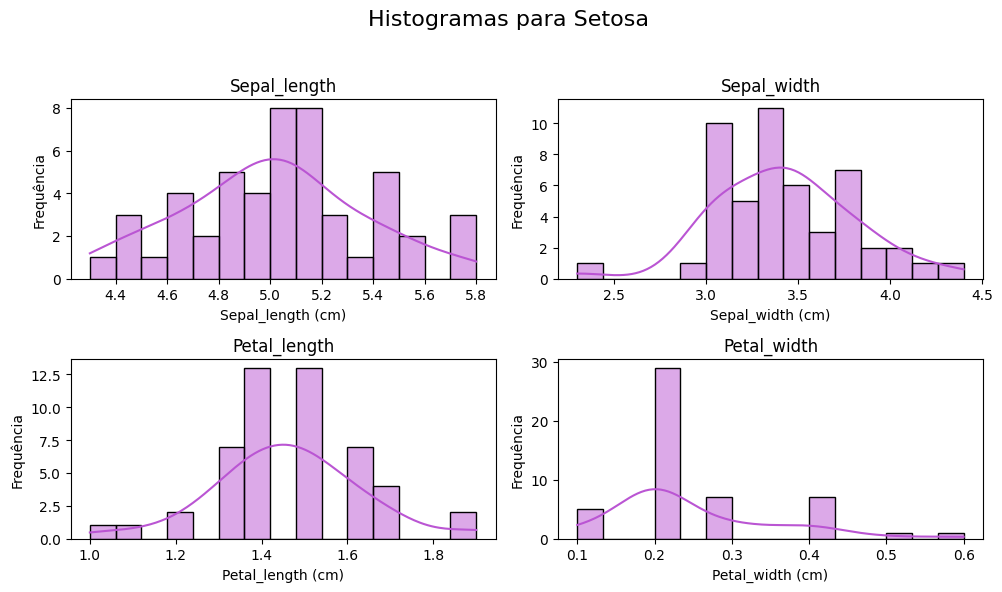

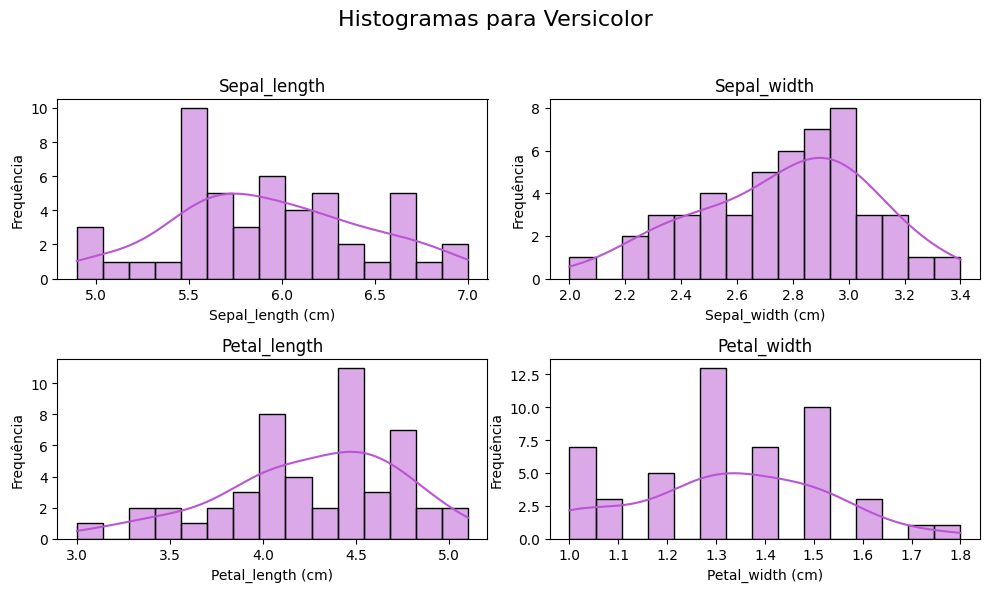

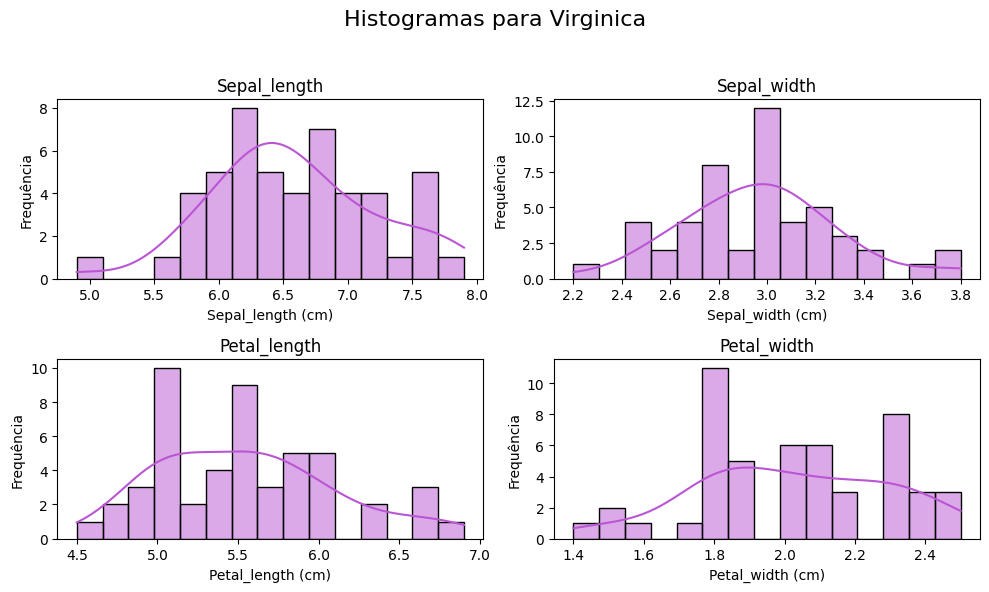

In [ ]:
for specie in lista_especies:
    iris_specie = df_iris[df_iris['Species'] == specie]  # Filtrar por espécie
    fig, axes = plt.subplots(2, 2, figsize=(10, 6))  # Subplots para 4 histogramas


    # Iterar sobre as colunas e eixos para plotar cada histograma
    for col, ax in zip(df_iris_num, axes.flatten()):
        sns.histplot(iris_specie[col], bins=15, kde=True, color='MediumOrchid', edgecolor='black', ax=ax)
        ax.set_title(f'{col.capitalize()}')
        ax.set_xlabel(f'{col.capitalize()} (cm)')
        ax.set_ylabel('Frequência')

    plt.suptitle(f"Histogramas para {specie.capitalize()}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


### Boxplots

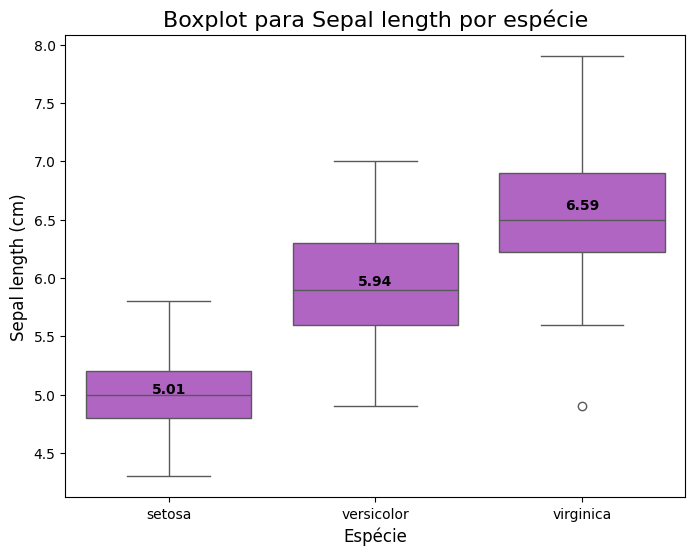

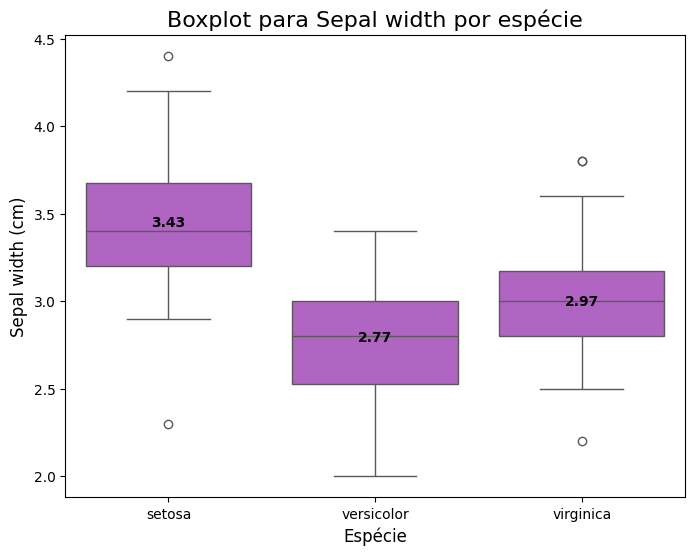

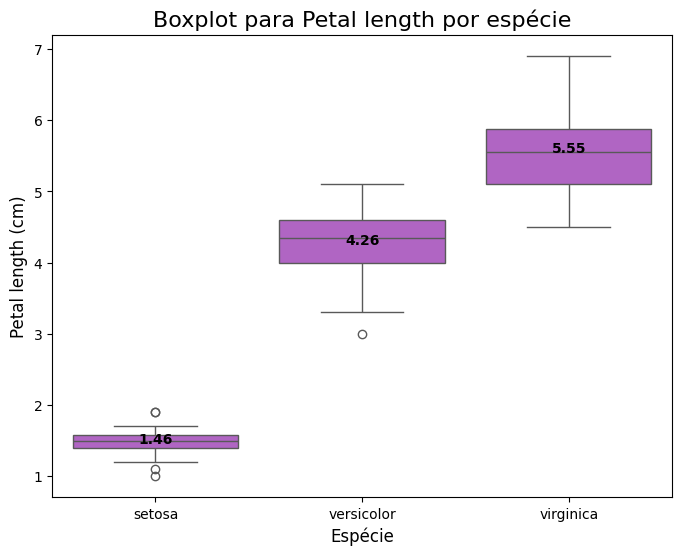

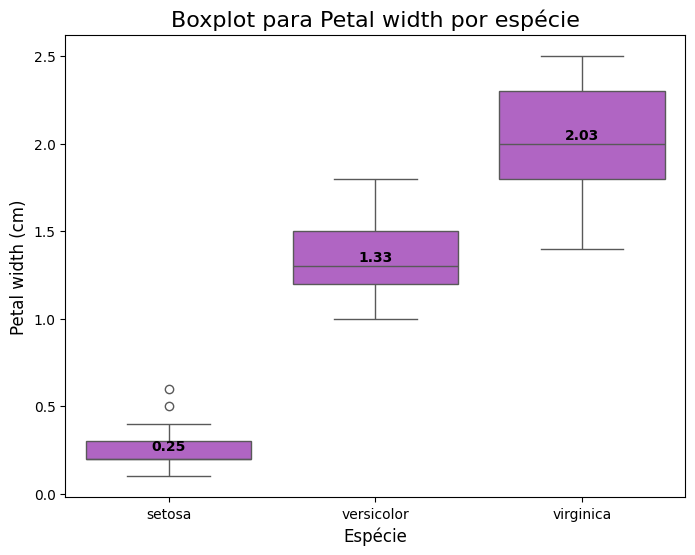

In [ ]:
for col in df_iris_num:
    plt.figure(figsize=(8, 6))

    ax = sns.boxplot(x='Species', y=col, data=df_iris, color='MediumOrchid')

    # Calcular a média para cada grupo
    media = df_iris.groupby('Species')[col].mean().values

    # Adicionar os valores de média em cima de cada boxplot
    for i, medias in enumerate(media):
        ax.text(i, medias, f'{medias:.2f}', horizontalalignment='center', fontweight='bold', color='black')

    # Adicionar títulos e labels
    plt.title(f'Boxplot para {col.replace("_", " ").capitalize()} por espécie', fontsize=16)
    plt.xlabel('Espécie', fontsize=12)
    plt.ylabel(f'{col.replace("_", " ").capitalize()} (cm)', fontsize=12)

    plt.show()


c. Somente olhando esses gráficos, é possível afirmar que uma ou mais propriedades (Sepal_Length, Sepal_Width, Petal_Length, Petal_Width) são suficientes para distinguir as espécies?

* **Petal Lenght (cm) e Petal Width (cm)**

É possível observar que a espécie Setosa possui, em média, valores menores para essas propriedades (1.46 cm e 0.25 cm, respectivamente) quando comparada às outras espécies da flor Íris.

* **Sepal Lenght (cm) e Sepal Width (cm)**

Observando a média de valores, essas propriedades sozinhas podem não ser suficientes para distinguir a espécies. Contudo, são mais eficientes para diferencia a espécie Setosa já que possui, em média, uma largura de sépala maior (3.48 cm) e um comprimento de sépala menor (5.01 cm), em comparação às outras espécies.

d. Aplique a regressão logística para avaliar o modelo de classificação.

#### Matriz de Correlação

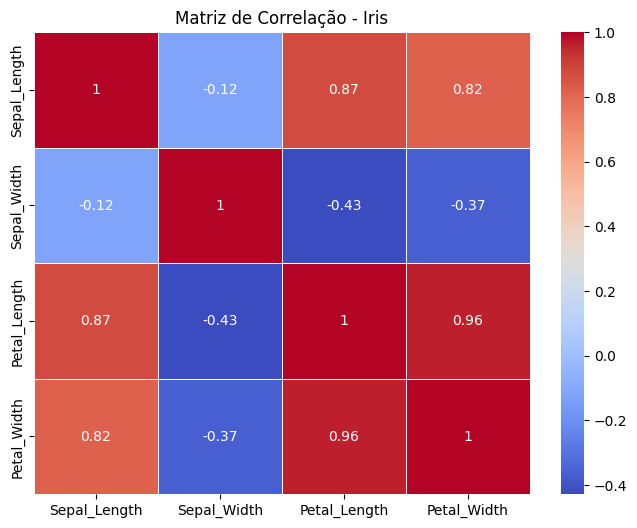

In [ ]:
# Criando matriz de correlação
corr = df_iris_num.corr()

# Plotando
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlação - Iris')
plt.show()

#### Regressão Logística

In [ ]:
# Variável alvo
y = df_iris['Species']

# Variáveis explicativas
X = df_iris.drop('Species', axis=1)

# Separando dos dfs de Treino e Teste (80% e 20%)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit do modelo
from sklearn.linear_model import LogisticRegression
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

# Aplicando o modelo fitado na base Teste
y_pred = modelo.predict(X_test)
y_pred_prob = modelo.predict_proba(X_test)

In [ ]:
# Adicionando previsão e probabilidade na base de Teste para cada espécie
X_test['previsão modelo'] = y_pred
X_test['prob setosa'] = y_pred_prob[:, 0].round(2)
X_test['prob versicolor'] = y_pred_prob[:, 1].round(2)
X_test['prob virginica'] = y_pred_prob[:, 2].round(2)

X_test.head()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,previsão modelo,prob setosa,prob versicolor,prob virginica
73,6.1,2.8,4.7,1.2,versicolor,0.00,0.83,0.17
18,5.7,3.8,1.7,0.3,setosa,0.95,0.05,0.00
118,7.7,2.6,6.9,2.3,virginica,0.00,0.00,1.00
78,6.0,2.9,4.5,1.5,versicolor,0.01,0.79,0.20
76,6.8,2.8,4.8,1.4,versicolor,0.00,0.77,0.22


e. Calcule a acurácia, precisão e recall.

In [ ]:
from sklearn import metrics

acuracia = metrics.accuracy_score(y_test, y_pred)
precisao = metrics.precision_score(y_test, y_pred, average='macro')
recall = metrics.recall_score(y_test, y_pred, average='macro')

print(f'Acurácia: {acuracia:.2f}')
print(f'Precisão: {precisao:.2f}')
print(f'Recall: {recall:.2f}')

Acurácia: 1.00
Precisão: 1.00
Recall: 1.00


f. Plote a matriz de confusao com matplotlib ou seaborn

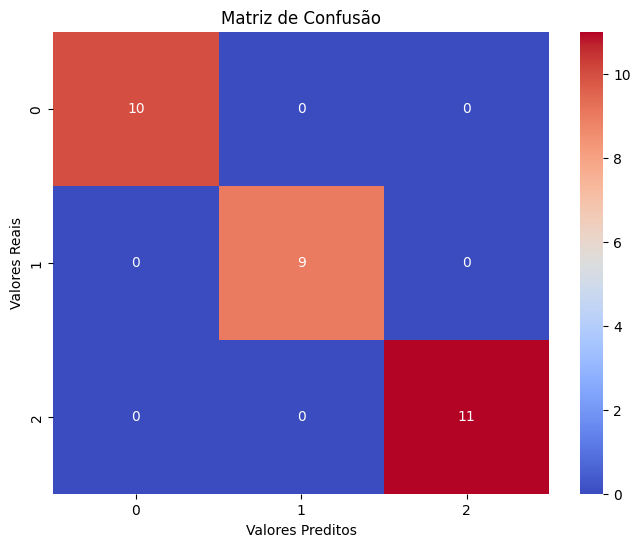

In [ ]:
# Criando a matriz de confusão
matriz_confusao = metrics.confusion_matrix(y_test, y_pred)

# Plotando a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusao, annot=True, cmap='coolwarm')
plt.xlabel('Valores Preditos')
plt.ylabel('Valores Reais')
plt.title('Matriz de Confusão')
plt.show()

# Questão 02

2. Utilizando o dataset load_digits

a. Faça uma análise inicial sobre esse dataset

i. Quantos dados possui?

ii. Existem dados nulos? Se sim quantos?

iii. Todos são dados numéricos ou existem colunas com dados categóricos?

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()

In [ ]:
df_digits = pd.DataFrame(digits.data, columns=digits.feature_names)
df_digits['target'] = digits.target
df_digits.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [ ]:
print(f'Quantidade de Registros: {df_digits.shape[0]}')
print(f'Quantidade de Colunas:{df_digits.shape[1]}')

Quantidade de Registros: 1797
Quantidade de Colunas:65


In [ ]:
nulos = df_digits.isnull().sum()
print(nulos)

pixel_0_0    0
pixel_0_1    0
pixel_0_2    0
pixel_0_3    0
pixel_0_4    0
            ..
pixel_7_4    0
pixel_7_5    0
pixel_7_6    0
pixel_7_7    0
target       0
Length: 65, dtype: int64


In [ ]:
df_digits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pixel_0_0  1797 non-null   float64
 1   pixel_0_1  1797 non-null   float64
 2   pixel_0_2  1797 non-null   float64
 3   pixel_0_3  1797 non-null   float64
 4   pixel_0_4  1797 non-null   float64
 5   pixel_0_5  1797 non-null   float64
 6   pixel_0_6  1797 non-null   float64
 7   pixel_0_7  1797 non-null   float64
 8   pixel_1_0  1797 non-null   float64
 9   pixel_1_1  1797 non-null   float64
 10  pixel_1_2  1797 non-null   float64
 11  pixel_1_3  1797 non-null   float64
 12  pixel_1_4  1797 non-null   float64
 13  pixel_1_5  1797 non-null   float64
 14  pixel_1_6  1797 non-null   float64
 15  pixel_1_7  1797 non-null   float64
 16  pixel_2_0  1797 non-null   float64
 17  pixel_2_1  1797 non-null   float64
 18  pixel_2_2  1797 non-null   float64
 19  pixel_2_3  1797 non-null   float64
 20  pixel_2_

O dataset em questão possui 1797 registros distribuidos em 65 colunas. Usando a função `.info()` é possível observar que o dataset só tem variáveis númericas (float e int) e, somado ao uso do `.isnull.sum()` confirmamos que não há valores nulos.

b. Aplique a regressão logística para avaliar o modelo de classificação.

In [ ]:
# Variável alvo
y = df_digits['target']

# Variáveis explicativas
X = df_digits.drop(['target'], axis=1)

# Separando dfs de treino e de teste (80% e 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit do modelo
modelo1 = LogisticRegression(max_iter=200)
modelo1.fit(X_train, y_train)

# Aplicando o modelo na base de teste
y_pred = modelo1.predict(X_test)
y_pred_prob = modelo1.predict_proba(X_test)

In [ ]:
# Adicionando previsão e probabilidade
X_test['previsao_modelo'] = y_pred
X_test['probabilidade_modelo'] = y_pred_prob.max(axis=1).round(2)

X_test[['previsao_modelo', 'probabilidade_modelo']].head()

,previsao_modelo,probabilidade_modelo
1245,6,1.00
220,9,1.00
1518,3,1.00
438,7,1.00
1270,2,0.98


c. Calcule a acurácia, precisão e recall.

In [ ]:
acuracia = metrics.accuracy_score(y_test, y_pred)
precisao = metrics.precision_score(y_test, y_pred, average='macro')
recall = metrics.recall_score(y_test, y_pred, average='macro')

print(f'Acurácia: {acuracia:.2f}')
print(f'Precisão: {precisao:.2f}')
print(f'Recall: {recall:.2f}')

Acurácia: 0.97
Precisão: 0.98
Recall: 0.98


d. Plote a matriz de confusão com matplotlib ou seaborn

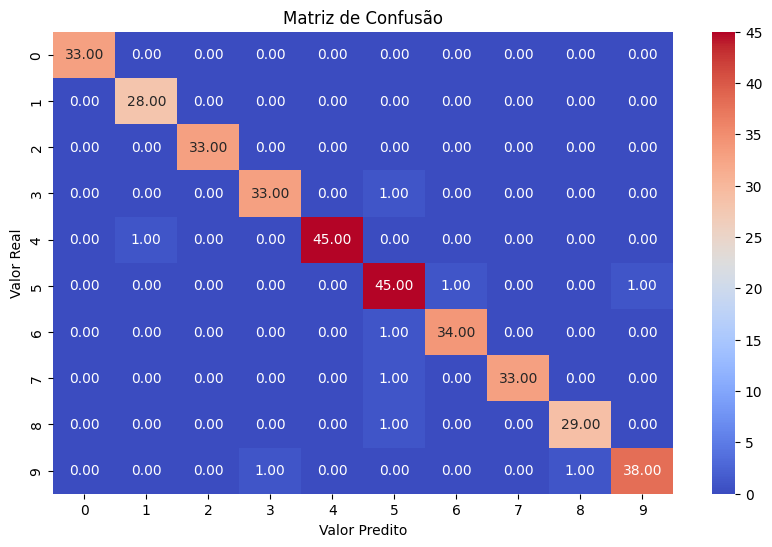

In [ ]:
# Criando matriz de confusão
confusion_matrix = metrics.confusion_matrix(y_test, y_pred)

# Plotando a matriz de confusão
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Confusão')
plt.xlabel('Valor Predito')
plt.ylabel('Valor Real')

plt.show()

e. Aplique a regressão logística para avaliar o modelo de classificação dos dígitos de 0-9 que são disponibilizados neste dataset.

Acurácia do modelo: 0.9722
Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       0.97      0.97      0.97        34
           4       1.00      0.98      0.99        46
           5       0.94      0.94      0.94        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.97      0.97      0.97        30
           9       0.93      0.95      0.94        40

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



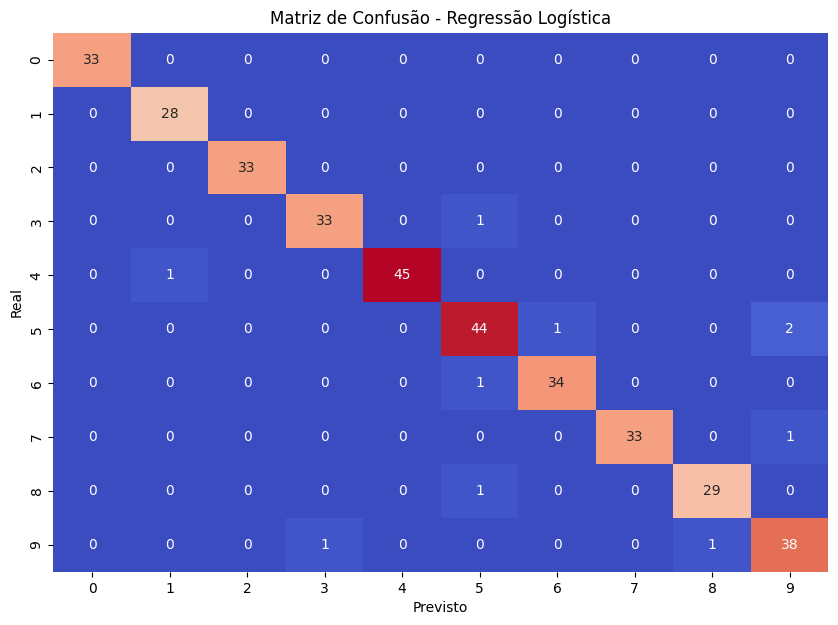

In [ ]:
# Importando bibliotecas

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Variável alvo e explicativas
X = digits.data  # Imagens dos dígitos em formato de vetores (64 features por imagem)
y = digits.target  # Classes (dígitos 0-9)

# 3. Dividir os dados em conjunto de treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Escalonar os dados (opcional, mas melhora o desempenho)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Treinar o modelo de Regressão Logística
modelo = LogisticRegression(max_iter=10000)  # Definindo um número maior de iterações
modelo.fit(X_train_scaled, y_train)

# 6. Fazer previsões no conjunto de teste
y_pred = modelo.predict(X_test_scaled)

# 7. Avaliar o desempenho do modelo
# Métrica de acurácia
accuracy = accuracy_score(y_test, y_pred)
print(f'Acurácia do modelo: {accuracy:.4f}')

# Relatório de classificação (precision, recall, f1-score)
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)

# Exibir a matriz de confusão
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", cbar=False, xticklabels=digits.target_names, yticklabels=digits.target_names)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Regressão Logística')
plt.show()



f. Calcule a acurácia, precisão e recall com base no desempenho do modelo para a classificação dos dígitos de 0 a 9.

In [ ]:
# Importar bibliotecas necessárias
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

# Dividir os dados em conjunto de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Treinar um modelo de Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Fazer predições
y_pred = model.predict(X_test)

# Calcular acurácia, precisão e recall
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred, output_dict=True)

# Extrair precisão, recall e f1-score médios
precision = classification_rep['macro avg']['precision']
recall = classification_rep['macro avg']['recall']

print(f'Acurácia: {accuracy:.2f}')
print(f'Precisão: {precision:.2f}')
print(f'Recall: {recall:.2f}')


Acurácia: 0.98
Precisão: 0.98
Recall: 0.98


g. Plote a matriz de confusão dos resultados da classificação dos dígitos de 0 a 9 utilizando matplotlib ou seaborn

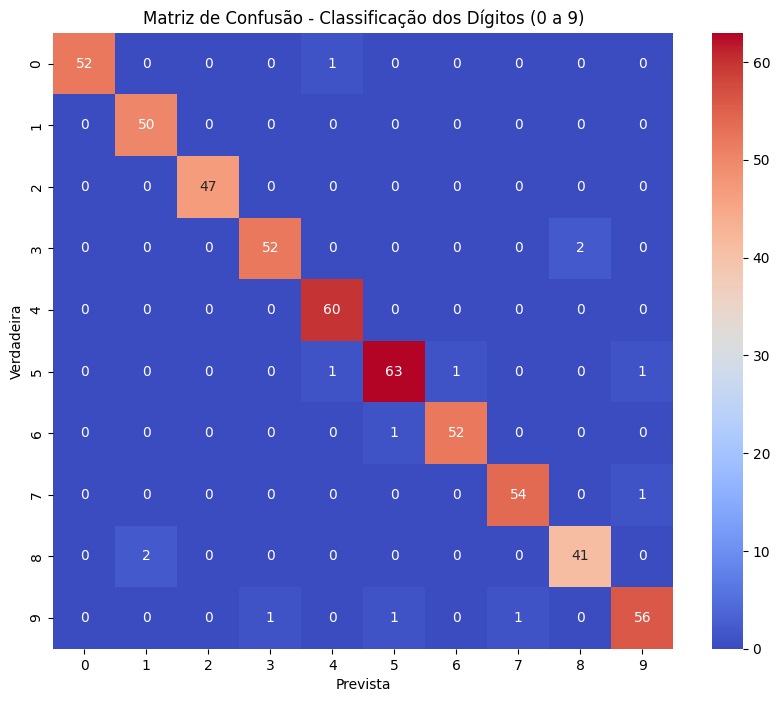

In [ ]:
# Calcular a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotar a matriz de confusão usando Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='coolwarm', xticklabels=digits.target_names, yticklabels=digits.target_names)
plt.title("Matriz de Confusão - Classificação dos Dígitos (0 a 9)")
plt.xlabel("Prevista")
plt.ylabel("Verdadeira")
plt.show()
